# Havlicek Benchmark

Havlicek dataset has to yield:
- 0.5 accuracy in classical kernel $\rightarrow$ done
- 1.0 accuracy in quantum kernel

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from config.config import *
from config.experiments import ExperimentConfig
from src.data.preprocessing import preprocess_synthetic
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.data.synthetic import *
from src.utils.visuals import *
from src.optimization.classical_base import classical_benchmark

RESULTS_DIR = 'Results/Havlicek Benchmark'

## 0. Classical Performance

In [3]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_classical = []
errs_classical = []
for delta in deltas:
    accs = []
    for seed in range(10):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classical.append(np.mean(accs))
    errs_classical.append(np.std(accs))

data = {'deltas': deltas, 'accuracies_classical': accuracies_classical, 'errs_classical': errs_classical}
df = pd.DataFrame(data)
df.to_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv', index=False)

In [4]:
# open the csv file and plot the results
df = pd.read_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv')
deltas, accuracies_classical, errs_classical = df['deltas'], df['accuracies_classical'], df['errs_classical']

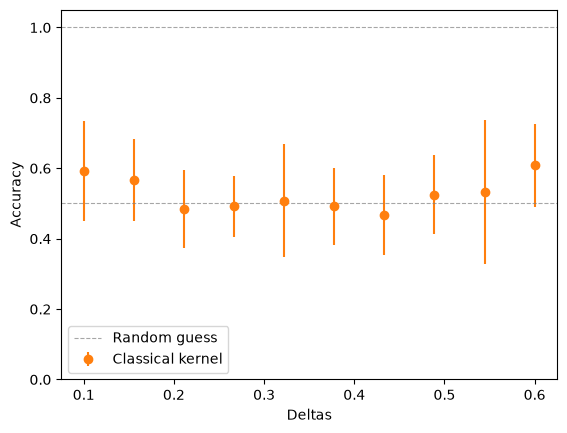

In [5]:
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 1. Original Kernel

- Add rescaling to preprocess

In [ ]:
def preprocess_synthetic_new(X, y, tts_seed=TTS_SEED):
    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=tts_seed, stratify=y)

    # Scale features to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [ ]:
delta = 0.5
accuracies_qo = []

config = ExperimentConfig(
    name = f'{RESULTS_DIR}/optuna 100 d{delta}',
    optimizer = 'optuna',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_trials': 100},
)
for seed in range(9):
    config.name = f'{RESULTS_DIR}/optuna 100 d{delta} s{seed}'
    X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
    X_train, X_test, y_train, y_test = preprocess_synthetic_new(X, y, N_QUBITS)
    
    trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    accuracies_qo.append(results['accuracy'])
    
    unique, counts = np.unique(results['y_pred'], return_counts=True)
    print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")

Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s0'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s0'
delta= 0.5 seed=0: acc=0.417, predicted counts={-1: 5, 1: 7}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s1'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s1'
delta= 0.5 seed=1: acc=0.750, predicted counts={-1: 5, 1: 7}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s2'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s2'
delta= 0.5 seed=2: acc=0.417, predicted counts={-1: 7, 1: 5}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s3'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s3'
delta= 0.5 seed=3: acc=0.667, predicted counts={-1: 8, 1: 4}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s4'
Loading cached SVM results for 'Results/Havlicek Benchm

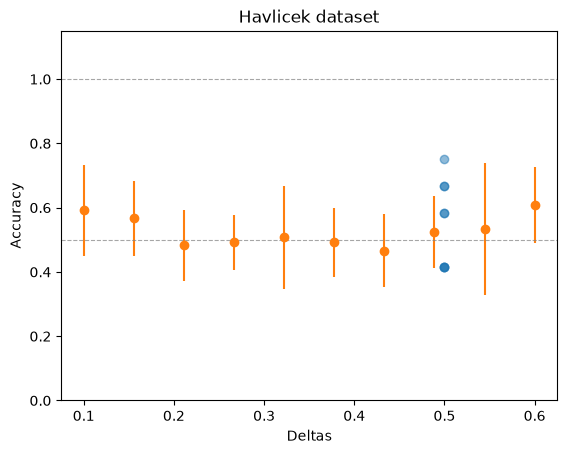

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
for n in range(9):
    plt.scatter(delta, accuracies_qo[n], color='tab:blue', alpha=0.5, label='Quantum kernel' if n==0 else None)
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 2. Kernel with phases

Now the candidate has `N_LAYERS` worth of rotation gates after a stage of entangling. The new candidate:
- Reuses `OptunaGene`class
- 

In [ ]:
import numpy as np
import optuna
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

from config.config import N_QUBITS, N_LAYERS, N_TRIALS
from config.experiments import ExperimentConfig
from src.circuit.candidates import Candidate
from src.circuit.genes import OptunaGene
from src.kernel.metrics import geometric_difference
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.data.saving import (
    candidate_exists, load_parameter_train, save_parameter_train,
    svm_exists, load_svm_results, save_svm_results,
)


# ── Candidate + circuit + kernel ─────────────────────────────────────────

class HavlicekCandidate(Candidate):
    def __init__(self, n_qubits: int, n_layers: int, gates: list, angles: list):
        super().__init__(n_qubits, n_layers)
        for gate, angle in zip(gates, angles):
            self.genes.append(OptunaGene(gate, angle))


def quantum_kernel_matrix_phases(candidate, X1, X2=None):

    def build_circuit(x):
        gene_idx = 0

        # entangling phase (non-parametrized)
        for qubit in range(candidate.n_qubits):
            qml.Hadamard(wires=qubit)
        for qubit in range(candidate.n_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])

        # rotation phase (parametrized)
        for layer in range(candidate.n_layers):
            for qubit in range(candidate.n_qubits):
                gene = candidate.get_ith_gene(gene_idx)
                info = gene.get_gene_info()
                gate, angle = info['gate'], info['angle']

                if gate == 'RX':
                    qml.RX(angle * x[qubit], wires=qubit)
                elif gate == 'RY':
                    qml.RY(angle * x[qubit], wires=qubit)
                elif gate == 'RZ':
                    qml.RZ(angle * x[qubit], wires=qubit)
                elif gate == 'I':
                    pass
                gene_idx += 1

    dev = qml.device('default.qubit', wires=candidate.n_qubits)

    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2)  # type: ignore
        return qml.probs(wires=range(candidate.n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K = np.zeros((N, N))
        for i in range(N):
            for j in range(i, N):
                K[i, j] = K[j, i] = quantum_kernel(X1[i], X1[j])
        return K

    N1, N2 = len(X1), len(X2)
    K = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            K[i, j] = quantum_kernel(X1[i], X2[j])
    return K


# ── Objective + training ─────────────────────────────────────────────────

def objective_optuna_generator_RD_phases(X):
    gamma = 1.0 / (N_QUBITS * X.var())
    K_classical = rbf_kernel(X, gamma=gamma)

    def objective(trial):
        n_genes = N_LAYERS * N_QUBITS
        gates  = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 2 * np.pi) for i in range(n_genes)]

        candidate = HavlicekCandidate(N_QUBITS, N_LAYERS, gates, angles)
        K_quantum = quantum_kernel_matrix_phases(candidate, X)
        return geometric_difference(K_classical, K_quantum)

    return objective

from src.kernel.metrics import kernel_target_alignment

def objective_optuna_KTA_generator_phases(X, y):
    def objective(trial):
        n_genes = N_LAYERS * N_QUBITS
        gates  = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 2 * np.pi) for i in range(n_genes)]

        candidate = HavlicekCandidate(N_QUBITS, N_LAYERS, gates, angles)
        K_quantum = quantum_kernel_matrix_phases(candidate, X)
        return kernel_target_alignment(K_quantum, y)

    return objective


def train_candidate_optuna_RD_phases(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_generator_RD_phases(X_train), n_trials=n_trials)

    n_genes = n_layers * n_qubits
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = HavlicekCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_phases(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0 / (n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical

def train_candidate_optuna_KTA_phases(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_KTA_generator_phases(X_train, y_train), n_trials=n_trials)

    n_genes = n_layers * n_qubits
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = HavlicekCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_phases(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0 / (n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical


# ── ExperimentConfig-style pipeline ──────────────────────────────────────

_SUBSET_METHODS = {
    'random':             subset_random,
    'nystrom_global':     subset_nystrom_global,
    'nystrom_stratified': subset_nystrom_stratified,
    'none':               None,
}
_TRAIN_FUNCTIONS = {
    'geometric': train_candidate_optuna_RD_phases,
    'kta':       train_candidate_optuna_KTA_phases,
}

def get_candidate_phases(config: ExperimentConfig, X_train, y_train):
    load_name = config.load_from or config.name

    if candidate_exists(load_name):
        print(f"Loading cached candidate for '{load_name}'")
        data = load_parameter_train(load_name)
        return data['candidate'], data['K_quantum'], data['K_classical'], data['X_subset'], data['y_subset']

    if _SUBSET_METHODS[config.subset_method] is None:
        X_sub, y_sub = X_train, y_train
    else:
        subset_fn = _SUBSET_METHODS[config.subset_method]
        _, X_sub, y_sub = subset_fn(X_train, y_train, **config.subset_kwargs)

    train_fn = _TRAIN_FUNCTIONS[config.variant]
    _, candidate, K_q, K_c = train_fn(config.name, X_sub, y_sub, **config.optimizer_kwargs)
    return candidate, K_q, K_c, X_sub, y_sub


def get_svm_results_phases(config: ExperimentConfig, K_train, y_train, K_test, y_test, c_range=None, cv=5):
    if svm_exists(config.name):
        print(f"Loading cached SVM results for '{config.name}'")
        return load_svm_results(config.name)

    if c_range is None:
        c_range = {'C': [0.1, 1, 10, 100, 1000]}

    grid = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=cv, scoring='balanced_accuracy',
    )
    grid.fit(K_train, y_train)
    y_pred = grid.best_estimator_.predict(K_test)

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'best_C': grid.best_params_['C'],
        'best_cv_accuracy': grid.best_score_,
        'y_pred': y_pred, 'y_test': y_test, 'K_test': K_test,
        'report': classification_report(y_test, y_pred, zero_division=0),
    }
    save_svm_results(config.name, results)
    return results

Call the experiments

In [ ]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_qphases, errs_qphases = [], []
for delta in deltas:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'{RESULTS_DIR}/optuna kta delta{delta:.2f}_seed{seed}',
            optimizer='optuna',
            variant='kta',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100},
        )

        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_phases(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = quantum_kernel_matrix_phases(candidate, X_test, X_sub)

        results = get_svm_results_phases(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])

    accuracies_qphases.append(np.mean(accs))
    errs_qphases.append(np.std(accs))

[I 2026-08-26 19:36:53,493] A new study created in memory with name: no-name-9d2b771a-8a08-4be8-bab1-fe48e98d23ae
[I 2026-08-26 19:36:56,121] Trial 0 finished with value: 0.13609111497682463 and parameters: {'gate_0': 'I', 'gate_1': 'I', 'gate_2': 'I', 'gate_3': 'RY', 'gate_4': 'RX', 'gate_5': 'RZ', 'gate_6': 'RX', 'gate_7': 'RZ', 'gate_8': 'RZ', 'gate_9': 'I', 'gate_10': 'RZ', 'gate_11': 'I', 'gate_12': 'RZ', 'gate_13': 'RX', 'gate_14': 'RZ', 'gate_15': 'RZ', 'angle_0': 5.135927745858287, 'angle_1': 6.1493083977226926, 'angle_2': 0.8429174970874465, 'angle_3': 4.54496661415111, 'angle_4': 0.41793210028576905, 'angle_5': 2.370029232560884, 'angle_6': 4.681067682376516, 'angle_7': 2.839250467009943, 'angle_8': 0.15543379485012399, 'angle_9': 1.8011940673138562, 'angle_10': 3.3735448978398996, 'angle_11': 6.135031257972959, 'angle_12': 1.3376916752376469, 'angle_13': 5.836821022673011, 'angle_14': 2.255062274410418, 'angle_15': 3.519842592689462}. Best is trial 0 with value: 0.1360911149

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta delta0.10_seed0/candidate.pkl
Computing cross-kernel (delta=0.10, seed=0)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta delta0.10_seed0/svm.pkl


[I 2026-08-26 19:41:52,333] A new study created in memory with name: no-name-f5035bfb-3949-43b2-b0d1-1955d7bc6c6e
[I 2026-08-26 19:41:54,994] Trial 0 finished with value: 0.052526361945443564 and parameters: {'gate_0': 'RX', 'gate_1': 'RX', 'gate_2': 'RX', 'gate_3': 'I', 'gate_4': 'I', 'gate_5': 'I', 'gate_6': 'RX', 'gate_7': 'RX', 'gate_8': 'I', 'gate_9': 'RX', 'gate_10': 'I', 'gate_11': 'RZ', 'gate_12': 'I', 'gate_13': 'RX', 'gate_14': 'RX', 'gate_15': 'RX', 'angle_0': 4.47166121619189, 'angle_1': 6.233143369309656, 'angle_2': 2.8998869610967803, 'angle_3': 1.4358318066136535, 'angle_4': 2.163326262210532, 'angle_5': 2.5984519478214634, 'angle_6': 5.917826206283236, 'angle_7': 4.364467915455229, 'angle_8': 4.414362006603123, 'angle_9': 3.7655881433043863, 'angle_10': 3.7483668594585984, 'angle_11': 5.392044105605, 'angle_12': 0.20849552294934706, 'angle_13': 2.623893538561389, 'angle_14': 3.9733974859912866, 'angle_15': 6.0868249733648}. Best is trial 0 with value: 0.0525263619454435

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta delta0.10_seed1/candidate.pkl
Computing cross-kernel (delta=0.10, seed=1)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta delta0.10_seed1/svm.pkl


[I 2026-08-26 19:46:18,607] A new study created in memory with name: no-name-738b9c96-96a6-454a-88d2-0b4d5ec3c5ec
[I 2026-08-26 19:46:21,402] Trial 0 finished with value: 0.1952676860744992 and parameters: {'gate_0': 'RZ', 'gate_1': 'I', 'gate_2': 'I', 'gate_3': 'RX', 'gate_4': 'I', 'gate_5': 'RY', 'gate_6': 'RX', 'gate_7': 'RY', 'gate_8': 'RY', 'gate_9': 'RY', 'gate_10': 'RZ', 'gate_11': 'RZ', 'gate_12': 'RX', 'gate_13': 'RX', 'gate_14': 'RY', 'gate_15': 'I', 'angle_0': 1.364159919138447, 'angle_1': 3.0911857786990895, 'angle_2': 3.464688071700273, 'angle_3': 1.2139812825246494, 'angle_4': 5.129431925875291, 'angle_5': 2.171209313125946, 'angle_6': 4.6502213669934545, 'angle_7': 4.531305562730911, 'angle_8': 1.392528890422683, 'angle_9': 2.662028614586892, 'angle_10': 5.488491059182879, 'angle_11': 0.7041876798118809, 'angle_12': 5.101500890662282, 'angle_13': 3.2515409161244966, 'angle_14': 0.9919822633178454, 'angle_15': 6.057463349234569}. Best is trial 0 with value: 0.195267686074

...

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed0/candidate.pkl
Computing cross-kernel (delta=0.60, seed=0)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed0/svm.pkl


[I 2026-08-26 21:56:30,706] A new study created in memory with name: no-name-07a8d6b6-044a-40e5-bdcf-0a24dae2c9ff
[I 2026-08-26 21:56:33,388] Trial 0 finished with value: 0.16895071455741517 and parameters: {'gate_0': 'I', 'gate_1': 'I', 'gate_2': 'RX', 'gate_3': 'RX', 'gate_4': 'RX', 'gate_5': 'RZ', 'gate_6': 'RX', 'gate_7': 'RY', 'gate_8': 'I', 'gate_9': 'RZ', 'gate_10': 'RX', 'gate_11': 'RZ', 'gate_12': 'RY', 'gate_13': 'RZ', 'gate_14': 'RX', 'gate_15': 'RY', 'angle_0': 1.1341524732015966, 'angle_1': 3.1134864216557077, 'angle_2': 2.576291099251346, 'angle_3': 0.009408027730056648, 'angle_4': 0.42183075691547073, 'angle_5': 2.1165741651863437, 'angle_6': 4.373813368521046, 'angle_7': 1.4260139376839422, 'angle_8': 5.34153708697949, 'angle_9': 3.990054021505143, 'angle_10': 0.2334321133054563, 'angle_11': 1.9510052161188594, 'angle_12': 4.508627731401002, 'angle_13': 1.6488608371120292, 'angle_14': 6.120069533980315, 'angle_15': 4.476706874948299}. Best is trial 0 with value: 0.16895

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed1/candidate.pkl
Computing cross-kernel (delta=0.60, seed=1)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed1/svm.pkl


[I 2026-08-26 22:01:40,356] A new study created in memory with name: no-name-85fe8ccb-7f47-4d05-b724-bc8ca858a164
[I 2026-08-26 22:01:42,857] Trial 0 finished with value: 0.15283868043927906 and parameters: {'gate_0': 'RZ', 'gate_1': 'RX', 'gate_2': 'RY', 'gate_3': 'RY', 'gate_4': 'RZ', 'gate_5': 'RY', 'gate_6': 'RX', 'gate_7': 'I', 'gate_8': 'RZ', 'gate_9': 'RY', 'gate_10': 'RY', 'gate_11': 'I', 'gate_12': 'I', 'gate_13': 'I', 'gate_14': 'RZ', 'gate_15': 'I', 'angle_0': 1.9072611149021872, 'angle_1': 0.3153901926348463, 'angle_2': 4.298721436144849, 'angle_3': 3.528853883456045, 'angle_4': 4.250252205748424, 'angle_5': 6.042755396653354, 'angle_6': 5.387858243220929, 'angle_7': 5.728134951054528, 'angle_8': 4.157374042988756, 'angle_9': 3.2163985585587667, 'angle_10': 4.445805661086157, 'angle_11': 4.278573565051341, 'angle_12': 4.273524435808091, 'angle_13': 2.397725995021203, 'angle_14': 5.395937024709693, 'angle_15': 2.3292617261858006}. Best is trial 0 with value: 0.15283868043927

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed2/candidate.pkl
Computing cross-kernel (delta=0.60, seed=2)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta delta0.60_seed2/svm.pkl


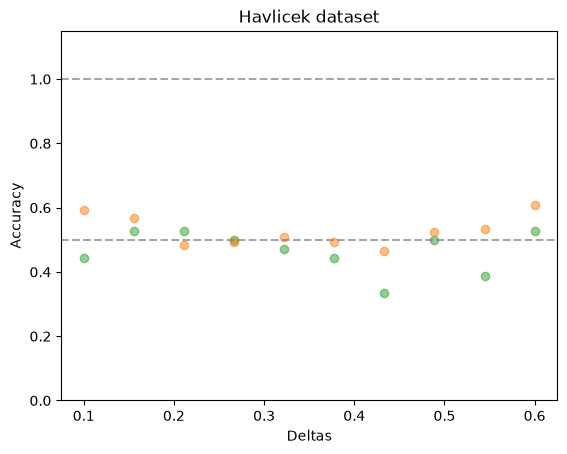

In [17]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_qphases, color='tab:green', alpha=0.5, label='Quantum Phases (kta)')
plt.scatter(deltas, accuracies_classical, color='tab:orange', alpha=0.5, label='Classical Kernel')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 3. Kernel with phases + entangling

In [24]:
deltas = np.linspace(0.1, 0.6, 5)
accuracies_qcross, errs_qcross = [], []
for delta in deltas:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'{RESULTS_DIR}/optuna kta_cross delta{delta:.2f}_seed{seed}',
            optimizer='optuna',
            variant='kta_cross',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100},
        )

        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_havlicek(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = _KERNEL_FUNCTIONS[config.variant](candidate, X_test, X_sub)

        results = get_svm_results_havlicek(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        print(f'Accuracy of delta {delta} | seed {seed}: ', results['accuracy'])

    accuracies_qcross.append(np.mean(accs))
    errs_qcross.append(np.std(accs))

Loading cached candidate for 'Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed0'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed0'
Accuracy of delta 0.1 | seed 0:  0.5


[I 2026-08-27 13:20:11,394] A new study created in memory with name: no-name-47d451b6-3edc-4949-afc5-952b22db62c5
[I 2026-08-27 13:20:20,858] Trial 0 finished with value: 0.1366527968664335 and parameters: {'gate_0': 'RY', 'gate_1': 'RX', 'gate_2': 'I', 'gate_3': 'I', 'gate_4': 'RX', 'gate_5': 'RX', 'gate_6': 'RY', 'gate_7': 'RZ', 'gate_8': 'RZ', 'gate_9': 'I', 'gate_10': 'I', 'gate_11': 'RX', 'gate_12': 'I', 'gate_13': 'RZ', 'gate_14': 'RX', 'gate_15': 'RX', 'angle_0': 4.655193301699431, 'angle_1': 1.429946593650175, 'angle_2': 4.238908935398777, 'angle_3': 0.08061106125576623, 'angle_4': 4.392564581140573, 'angle_5': 2.0938012179215293, 'angle_6': 2.4589546530942985, 'angle_7': 5.787935563623082, 'angle_8': 2.719331935970269, 'angle_9': 6.099880600591817, 'angle_10': 3.0876386919482224, 'angle_11': 4.196137607621819, 'angle_12': 0.1804077816888429, 'angle_13': 4.206229251360508, 'angle_14': 1.4550280568437421, 'angle_15': 5.455893770975983, 'pair_angle_0': 0.40349247915806763, 'pair_

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed1/candidate.pkl
Computing cross-kernel (delta=0.10, seed=1)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed1/svm.pkl
Accuracy of delta 0.1 | seed 1:  0.5


[I 2026-08-27 13:36:43,524] A new study created in memory with name: no-name-d1f9be5f-5609-4dde-8600-dbee9e4c8e5e
[I 2026-08-27 13:36:56,338] Trial 0 finished with value: 0.17306682019739095 and parameters: {'gate_0': 'I', 'gate_1': 'I', 'gate_2': 'RX', 'gate_3': 'RZ', 'gate_4': 'RZ', 'gate_5': 'RZ', 'gate_6': 'I', 'gate_7': 'RX', 'gate_8': 'RZ', 'gate_9': 'I', 'gate_10': 'RY', 'gate_11': 'RX', 'gate_12': 'RZ', 'gate_13': 'RX', 'gate_14': 'RY', 'gate_15': 'RY', 'angle_0': 5.5594646782132555, 'angle_1': 3.5168493976513098, 'angle_2': 6.09943782363891, 'angle_3': 1.4899103624371737, 'angle_4': 5.622380975167057, 'angle_5': 4.191473546703432, 'angle_6': 3.5058785654141618, 'angle_7': 0.19909742293359595, 'angle_8': 0.05103922619152815, 'angle_9': 0.057448442979902904, 'angle_10': 3.7762023949966466, 'angle_11': 0.9960093474873947, 'angle_12': 4.596821598929402, 'angle_13': 4.611290673612447, 'angle_14': 2.5501762753144925, 'angle_15': 5.320376129256501, 'pair_angle_0': 1.887355031139758, 

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed2/candidate.pkl
Computing cross-kernel (delta=0.10, seed=2)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.10_seed2/svm.pkl
Accuracy of delta 0.1 | seed 2:  0.5


...

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed0/candidate.pkl
Computing cross-kernel (delta=0.60, seed=0)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed0/svm.pkl
Accuracy of delta 0.6 | seed 0:  0.25


[I 2026-08-27 16:24:23,106] A new study created in memory with name: no-name-473070d3-8a25-4037-8c5b-17b63e5d763d
[I 2026-08-27 16:24:30,933] Trial 0 finished with value: 0.1453638897591355 and parameters: {'gate_0': 'I', 'gate_1': 'RZ', 'gate_2': 'RY', 'gate_3': 'RY', 'gate_4': 'RY', 'gate_5': 'RZ', 'gate_6': 'RY', 'gate_7': 'RX', 'gate_8': 'RX', 'gate_9': 'RX', 'gate_10': 'RX', 'gate_11': 'RY', 'gate_12': 'RY', 'gate_13': 'I', 'gate_14': 'RY', 'gate_15': 'I', 'angle_0': 4.547951910282383, 'angle_1': 4.055514847093063, 'angle_2': 4.948812208670645, 'angle_3': 0.36315102603907506, 'angle_4': 4.672323176767136, 'angle_5': 1.5073020532328032, 'angle_6': 3.9616991485927735, 'angle_7': 3.1674505703328513, 'angle_8': 4.17417311953868, 'angle_9': 1.9060445076874444, 'angle_10': 0.046469731740363826, 'angle_11': 1.4886569059889228, 'angle_12': 2.460834564390655, 'angle_13': 0.4206383239184979, 'angle_14': 0.9062805210869908, 'angle_15': 1.0281537376332996, 'pair_angle_0': 5.850039133603978, '

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed1/candidate.pkl
Computing cross-kernel (delta=0.60, seed=1)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed1/svm.pkl
Accuracy of delta 0.6 | seed 1:  0.6666666666666666


[I 2026-08-27 16:38:14,230] A new study created in memory with name: no-name-1b631842-630d-4b35-ac90-59a0d7dd9495
[I 2026-08-27 16:38:22,259] Trial 0 finished with value: 0.14560620144627404 and parameters: {'gate_0': 'RY', 'gate_1': 'RX', 'gate_2': 'RZ', 'gate_3': 'I', 'gate_4': 'RX', 'gate_5': 'I', 'gate_6': 'RY', 'gate_7': 'RY', 'gate_8': 'RY', 'gate_9': 'RX', 'gate_10': 'RY', 'gate_11': 'RY', 'gate_12': 'RY', 'gate_13': 'RY', 'gate_14': 'RZ', 'gate_15': 'I', 'angle_0': 5.3012843361195365, 'angle_1': 2.4564415246173583, 'angle_2': 2.9538176669518568, 'angle_3': 0.7300386909076164, 'angle_4': 2.970864419479778, 'angle_5': 0.9071556679751712, 'angle_6': 1.0078185248102893, 'angle_7': 3.2319474710131244, 'angle_8': 5.639604588102541, 'angle_9': 0.37851779580194245, 'angle_10': 2.6885936528002445, 'angle_11': 3.3348945583493808, 'angle_12': 1.7108955134842614, 'angle_13': 4.928235609367224, 'angle_14': 0.7730139773538801, 'angle_15': 1.2727633085216916, 'pair_angle_0': 1.805225076435074

Saved candidate  → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed2/candidate.pkl
Computing cross-kernel (delta=0.60, seed=2)…
Saved SVM        → Results/Results/Havlicek Benchmark/optuna kta_cross delta0.60_seed2/svm.pkl
Accuracy of delta 0.6 | seed 2:  0.5


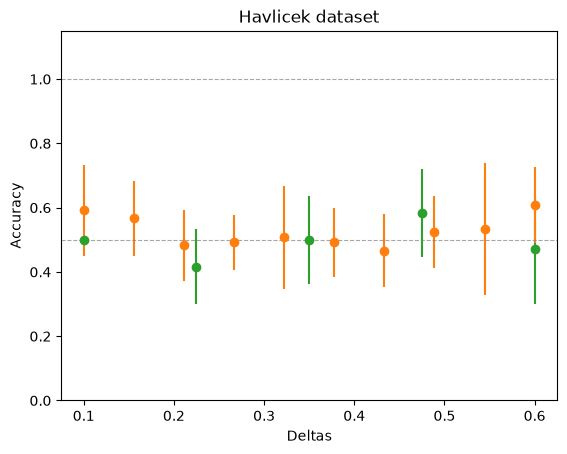

In [27]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.errorbar(deltas, accuracies_qcross, yerr=errs_qcross, label='Quantum Cross-feature (kta_cross)', color='tab:green', fmt='o')
deltas = np.linspace(0.1, 0.6, 10)
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 3. Kernel with Havlicek

New automated kernel; now:
1. Entangling phase
2. Rotation phase with CNOT + R + CNOT. Feature encoded here

In [6]:
import numpy as np
import optuna
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

from config.config import N_QUBITS, N_LAYERS, N_TRIALS
from config.experiments import ExperimentConfig
from src.circuit.candidates import OptunaCandidate
from src.circuit.genes import OptunaGene
from src.kernel.metrics import geometric_difference
from src.data.saving import (
    candidate_exists, load_parameter_train, save_parameter_train,
    svm_exists, load_svm_results, save_svm_results,
)
from src.kernel.metrics import kernel_target_alignment
import itertools

In [29]:
# HERE, THE ANGLES ARE PARAMETRIZED
# changed:
# - entangling phase
# - rotation angles
# - entangling comb
def n_genes_havlicek(n_qubits, n_layers):
    n_pairs = n_qubits * (n_qubits - 1) // 2
    return n_layers * n_pairs


def quantum_kernel_matrix_havlicek(candidate, X1, X2=None):

    def build_circuit(x):
        gene_idx = 0

        # entangling phase (non-parametrized)
        for qubit in range(candidate.n_qubits):
            qml.Hadamard(wires=qubit)
            qml.RZ(2 * x[qubit], wires=qubit)
            
        # rotation phase (parametrized)
        # NOTE: now all qubits are entangled
        for layer in range(candidate.n_layers):
            for i, j in itertools.combinations(range(candidate.n_qubits), 2):
                gene = candidate.get_ith_gene(gene_idx)
                info = gene.get_gene_info()
                gate, angle = info['gate'], info['angle']

                if gate in ('RX', 'RY', 'RZ'):
                    qml.CNOT(wires=[i, j])
                    getattr(qml, gate)(angle * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                    qml.CNOT(wires=[i, j])
                    
                gene_idx += 1

    dev = qml.device("default.qubit", wires=candidate.n_qubits)
    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2) # pyright: ignore[reportCallIssue]
        return qml.probs(wires=range(candidate.n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K_quantum = np.zeros((N, N))
        for i in range(N):
            for j in range(i, N):
                value = quantum_kernel(X1[i], X1[j])
                K_quantum[i, j] = value
                K_quantum[j, i] = value
    else:
        N1, N2 = len(X1), len(X2)
        K_quantum = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K_quantum[i, j] = quantum_kernel(X1[i], X2[j])
    return K_quantum

# ── Objective + training ─────────────────────────────────────────────────
# TODO: faltan funciones con geometric difference
def objective_optuna_generator_KTA_havlicek(X, y, n_qubits, n_layers):
    def objective(trial):
        n_genes = n_genes_havlicek(n_qubits, n_layers)
        gates = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 0.5) for i in range(n_genes)]

        candidate = OptunaCandidate(n_qubits, n_layers, gates, angles)
        K_quantum = quantum_kernel_matrix_havlicek(candidate, X)
        return kernel_target_alignment(K_quantum, y)
    return objective

def train_candidate_optuna_KTA_havlicek(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_generator_KTA_havlicek(X_train, y_train, n_qubits, n_layers), n_trials=n_trials)

    n_genes = n_genes_havlicek(n_qubits, n_layers)
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = OptunaCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_havlicek(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0/(n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical

# ── ExperimentConfig pipeline ───────────────────────────────────────────
_SUBSET_METHODS = {
    # 'random':             subset_random,
    # 'nystrom_global':     subset_nystrom_global,
    # 'nystrom_stratified': subset_nystrom_stratified,
    'none':               None,
}
_TRAIN_FUNCTIONS = {
    #'geometric': train_candidate_optuna_RD_havlicek,
    'kta':       train_candidate_optuna_KTA_havlicek,
}
def get_candidate_havlicek(config:ExperimentConfig, X_train, y_train):
    load_name = config.load_from or config.name

    if candidate_exists(load_name):
        print(f"Loading cached candidate for '{load_name}'")
        data = load_parameter_train(load_name)
        return data['candidate'], data['K_quantum'], data['K_classical'], data['X_subset'], data['y_subset']
    
    if _SUBSET_METHODS[config.subset_method] is None:
        X_sub, y_sub = X_train, y_train
    else:
        subset_fn = _SUBSET_METHODS[config.subset_method]
        _, X_sub, y_sub = subset_fn(X_train, y_train, **config.subset_kwargs) # pyright: ignore[reportOptionalCall]
    
    train_fn = _TRAIN_FUNCTIONS[config.variant]
    _, candidate, K_q, K_c = train_fn(config.name, X_sub, y_sub, **config.optimizer_kwargs)
    return candidate, K_q, K_c, X_sub, y_sub

def get_svm_results_havlicek(config: ExperimentConfig, K_train, y_train, K_test, y_test, c_range=None, cv=5):
    if svm_exists(config.name):
        print(f"Loading cached SVM results for '{config.name}'")
        return load_svm_results(config.name)

    if c_range is None:
        c_range = {'C': [0.1, 1, 10, 100, 1000]}

    grid = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=cv, scoring='balanced_accuracy',
    )
    grid.fit(K_train, y_train)
    y_pred = grid.best_estimator_.predict(K_test)

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'best_C': grid.best_params_['C'],
        'best_cv_accuracy': grid.best_score_,
        'y_pred': y_pred, 'y_test': y_test, 'K_test': K_test,
        'report': classification_report(y_test, y_pred, zero_division=0),
    }
    save_svm_results(config.name, results)
    return results

Call the experiments

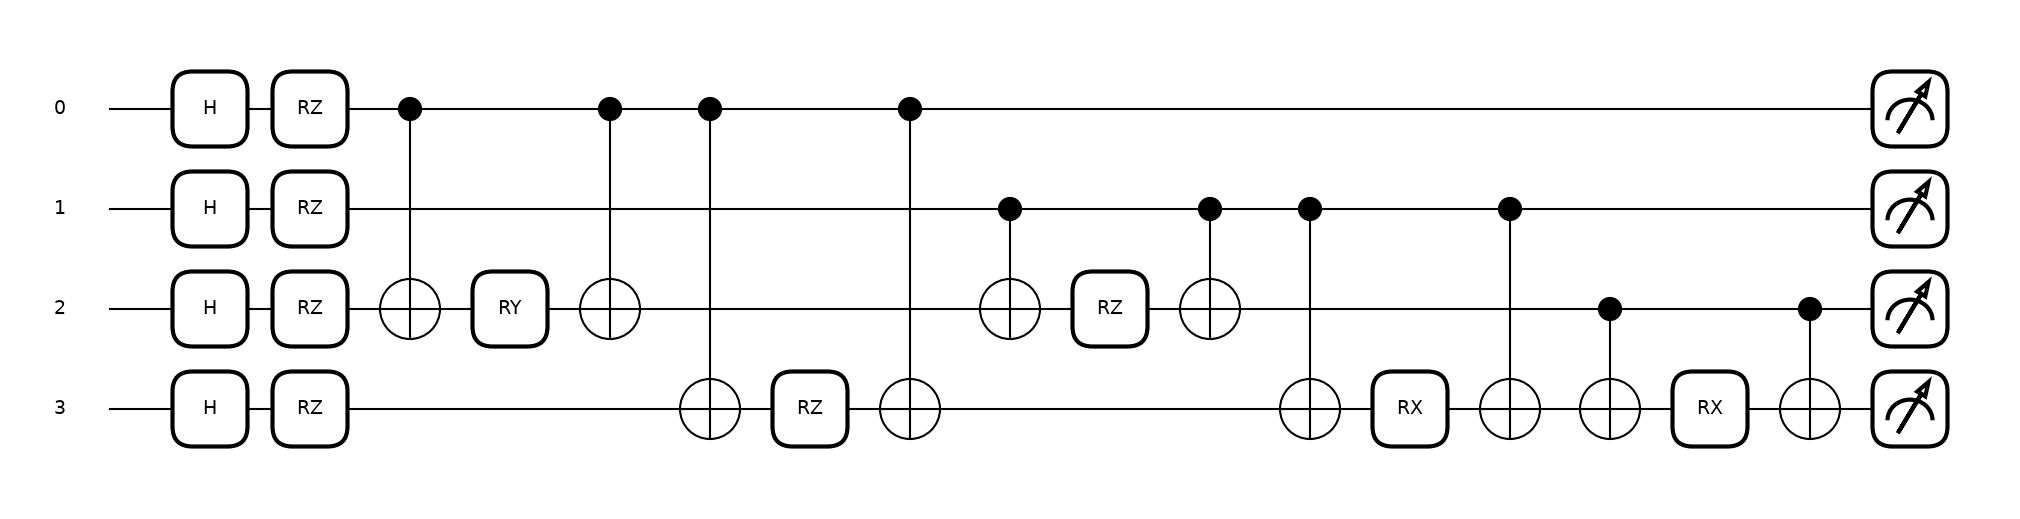

In [35]:
# example of random candidate
GATES = ("RX", "RY", "RZ", "I")
N_QUBITS = 4
N_LAYERS = 1

n_genes = n_genes_havlicek(N_QUBITS, N_LAYERS)

rng = np.random.default_rng()
gates = list(rng.choice(GATES, size=n_genes))
angles = list(rng.uniform(0, 2 * np.pi, size=n_genes))
random_candidate = OptunaCandidate(N_QUBITS, N_LAYERS, gates, angles)

x = rng.uniform(0, 2 * np.pi, size=N_QUBITS)

# print circuit — matches current quantum_kernel_matrix_havlicek's build_circuit
def build_circuit_havlicek(candidate, x):
    gene_idx = 0

    # entangling phase (non-parametrized) — data-dependent, no fixed CNOT chain
    for qubit in range(candidate.n_qubits):
        qml.Hadamard(wires=qubit)
        qml.RZ(2 * x[qubit], wires=qubit)

    # rotation phase (parametrized) — all-pairs
    for layer in range(candidate.n_layers):
        for i, j in itertools.combinations(range(candidate.n_qubits), 2):
            gene = candidate.get_ith_gene(gene_idx)
            info = gene.get_gene_info()
            gate, angle = info['gate'], info['angle']

            if gate in ('RX', 'RY', 'RZ'):
                qml.CNOT(wires=[i, j])
                getattr(qml, gate)(angle * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                qml.CNOT(wires=[i, j])
            # else: 'I', do nothing

            gene_idx += 1

dev = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev)
def draw_circuit(candidate, x):
    build_circuit_havlicek(candidate, x)
    return qml.probs(wires=range(N_QUBITS))

fig, ax = qml.draw_mpl(draw_circuit)(random_candidate, x)

In [36]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_havlicek, errs_havlicek = [], []

for delta in [0.5]:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(n_per_class=40, delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'Havlicek Benchmark/optuna kta havlicek c40 d{delta:.2f} s{seed}',
            optimizer='optuna',
            variant='kta',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100, 'n_layers': 1},
        )
        print(f"Training candidate for delta={delta:.2f}, seed={seed}, n_layers={config.optimizer_kwargs['n_layers']}")
        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_havlicek(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = quantum_kernel_matrix_havlicek(candidate, X_test, X_sub)

        results = get_svm_results_havlicek(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        print(f'Accuracy of delta {delta} | seed {seed}: ', results['accuracy'])

    accuracies_havlicek.append(np.mean(accs))
    errs_havlicek.append(np.std(accs))

[I 2026-08-31 11:26:54,775] A new study created in memory with name: no-name-be6dba48-5381-4533-9b59-022c4a5ae68a


Training candidate for delta=0.50, seed=0, n_layers=1


[I 2026-08-31 11:27:12,094] Trial 0 finished with value: 0.0989467609129709 and parameters: {'gate_0': 'RY', 'gate_1': 'RY', 'gate_2': 'RY', 'gate_3': 'RX', 'gate_4': 'RZ', 'gate_5': 'RZ', 'angle_0': 0.11113360042373283, 'angle_1': 0.4594140577231507, 'angle_2': 0.22847850775618972, 'angle_3': 0.21420828644743561, 'angle_4': 0.40284255669713254, 'angle_5': 0.34021307898272574}. Best is trial 0 with value: 0.0989467609129709.
[I 2026-08-31 11:27:29,371] Trial 1 finished with value: 0.11903436424698326 and parameters: {'gate_0': 'RX', 'gate_1': 'RZ', 'gate_2': 'RY', 'gate_3': 'RX', 'gate_4': 'RY', 'gate_5': 'RZ', 'angle_0': 0.07908178218753031, 'angle_1': 0.3704406088227198, 'angle_2': 0.4714712095714714, 'angle_3': 0.0828737844874583, 'angle_4': 0.10263132673017661, 'angle_5': 0.3544735938817865}. Best is trial 1 with value: 0.11903436424698326.
[I 2026-08-31 11:27:50,124] Trial 2 finished with value: 0.12467975978494193 and parameters: {'gate_0': 'I', 'gate_1': 'RX', 'gate_2': 'RY', 'g

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s0/candidate.pkl
Computing cross-kernel (delta=0.50, seed=0)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s0/svm.pkl
Accuracy of delta 0.5 | seed 0:  0.5


[I 2026-08-31 12:11:35,467] A new study created in memory with name: no-name-0fc2ab93-4f89-45d9-9db9-5a3be7b53c3d


...

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s1/candidate.pkl
Computing cross-kernel (delta=0.50, seed=1)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s1/svm.pkl
Accuracy of delta 0.5 | seed 1:  0.4583333333333333


[I 2026-08-31 12:48:06,183] A new study created in memory with name: no-name-f12be774-1879-435e-b948-cd7225bfcb12


Training candidate for delta=0.50, seed=2, n_layers=1


[I 2026-08-31 12:48:19,156] Trial 0 finished with value: 0.10270073805599941 and parameters: {'gate_0': 'RZ', 'gate_1': 'RX', 'gate_2': 'RZ', 'gate_3': 'I', 'gate_4': 'RX', 'gate_5': 'RX', 'angle_0': 0.051884718858715206, 'angle_1': 0.05664240128284437, 'angle_2': 0.30274511482172806, 'angle_3': 0.48714083368745814, 'angle_4': 0.30149740945436404, 'angle_5': 0.49988790643067343}. Best is trial 0 with value: 0.10270073805599941.
[I 2026-08-31 12:48:29,967] Trial 1 finished with value: 0.1296289466355912 and parameters: {'gate_0': 'RZ', 'gate_1': 'RY', 'gate_2': 'I', 'gate_3': 'RZ', 'gate_4': 'RY', 'gate_5': 'I', 'angle_0': 0.35742842880211834, 'angle_1': 0.27623407389887444, 'angle_2': 0.37068753238712765, 'angle_3': 0.3521002160340738, 'angle_4': 0.14456040577459545, 'angle_5': 0.2642147897698491}. Best is trial 1 with value: 0.1296289466355912.
[I 2026-08-31 12:48:37,611] Trial 2 finished with value: 0.10136686696346973 and parameters: {'gate_0': 'I', 'gate_1': 'I', 'gate_2': 'RY', 'g

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s2/candidate.pkl
Computing cross-kernel (delta=0.50, seed=2)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek c40 d0.50 s2/svm.pkl
Accuracy of delta 0.5 | seed 2:  0.625


In [37]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_havlicek, errs_havlicek = [], []

for delta in [0.5]:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(n_per_class=40, delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'Havlicek Benchmark/optuna kta havlicek i200 c40 d{delta:.2f} s{seed}',
            optimizer='optuna',
            variant='kta',
            subset_method='none',
            optimizer_kwargs={'n_trials': 200, 'n_layers': 1},
        )
        print(f"Training candidate for delta={delta:.2f}, seed={seed}, n_layers={config.optimizer_kwargs['n_layers']}")
        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_havlicek(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = quantum_kernel_matrix_havlicek(candidate, X_test, X_sub)

        results = get_svm_results_havlicek(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        print(f'Accuracy of delta {delta} | seed {seed}: ', results['accuracy'])

    accuracies_havlicek.append(np.mean(accs))
    errs_havlicek.append(np.std(accs))

[I 2026-08-31 13:08:46,008] A new study created in memory with name: no-name-cf748d6c-2440-42f9-9f30-e44e8aa9b9d1


Training candidate for delta=0.50, seed=0, n_layers=1


[I 2026-08-31 13:09:00,603] Trial 0 finished with value: 0.10231522542576332 and parameters: {'gate_0': 'RX', 'gate_1': 'I', 'gate_2': 'RZ', 'gate_3': 'RX', 'gate_4': 'RY', 'gate_5': 'RZ', 'angle_0': 0.3694957863119258, 'angle_1': 0.20141316123373393, 'angle_2': 0.07926480884704429, 'angle_3': 0.26274933740526757, 'angle_4': 0.11554701235762632, 'angle_5': 0.14690399555238415}. Best is trial 0 with value: 0.10231522542576332.
[I 2026-08-31 13:09:10,025] Trial 1 finished with value: 0.10303742573319147 and parameters: {'gate_0': 'RX', 'gate_1': 'RY', 'gate_2': 'RY', 'gate_3': 'I', 'gate_4': 'I', 'gate_5': 'I', 'angle_0': 0.011185161199785187, 'angle_1': 0.3501603675523813, 'angle_2': 0.29028316870003856, 'angle_3': 0.10590160193067194, 'angle_4': 0.013931994146127946, 'angle_5': 0.08224119136315555}. Best is trial 1 with value: 0.10303742573319147.
[I 2026-08-31 13:09:22,579] Trial 2 finished with value: 0.1260028370922608 and parameters: {'gate_0': 'RX', 'gate_1': 'RZ', 'gate_2': 'I', 

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s0/candidate.pkl
Computing cross-kernel (delta=0.50, seed=0)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s0/svm.pkl
Accuracy of delta 0.5 | seed 0:  0.5833333333333334


[I 2026-08-31 13:48:02,806] A new study created in memory with name: no-name-4a8719cd-f27f-405c-8b83-bf07c5aa4e8b


...

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s1/candidate.pkl
Computing cross-kernel (delta=0.50, seed=1)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s1/svm.pkl
Accuracy of delta 0.5 | seed 1:  0.75


[I 2026-08-31 14:33:02,850] A new study created in memory with name: no-name-7126c490-7f65-406a-bb94-d4c348274e41


Training candidate for delta=0.50, seed=2, n_layers=1


[I 2026-08-31 14:33:19,381] Trial 0 finished with value: 0.12476517619151728 and parameters: {'gate_0': 'I', 'gate_1': 'RY', 'gate_2': 'RX', 'gate_3': 'RZ', 'gate_4': 'RX', 'gate_5': 'RZ', 'angle_0': 0.3686382305874045, 'angle_1': 0.3286405139747102, 'angle_2': 0.3060650163011008, 'angle_3': 0.19476546275401668, 'angle_4': 0.12200394130991149, 'angle_5': 0.46034820409432214}. Best is trial 0 with value: 0.12476517619151728.
[I 2026-08-31 14:33:35,811] Trial 1 finished with value: 0.12358073323951889 and parameters: {'gate_0': 'RY', 'gate_1': 'RZ', 'gate_2': 'I', 'gate_3': 'RY', 'gate_4': 'RX', 'gate_5': 'RY', 'angle_0': 0.49594064029593576, 'angle_1': 0.40908037869890945, 'angle_2': 0.18305038458500783, 'angle_3': 0.20494444331804723, 'angle_4': 0.22935709593460196, 'angle_5': 0.3162337190740429}. Best is trial 0 with value: 0.12476517619151728.
[I 2026-08-31 14:33:52,299] Trial 2 finished with value: 0.12884750279887436 and parameters: {'gate_0': 'RY', 'gate_1': 'I', 'gate_2': 'RX', '

Saved candidate  → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s2/candidate.pkl
Computing cross-kernel (delta=0.50, seed=2)…
Saved SVM        → Results/Havlicek Benchmark/optuna kta havlicek i200 c40 d0.50 s2/svm.pkl
Accuracy of delta 0.5 | seed 2:  0.5416666666666666


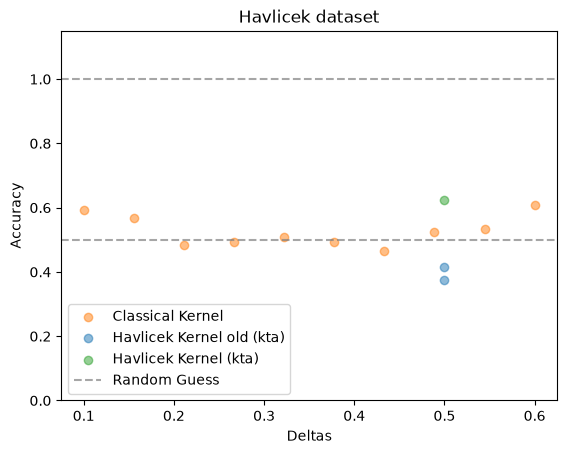

In [38]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_classical, color='tab:orange', alpha=0.5, label='Classical Kernel')
plt.scatter(np.ones(len(accs_old))*0.5, accs_old, color='tab:blue', alpha=0.5, label='Havlicek Kernel old (kta)')
plt.scatter(np.ones(len(accuracies_havlicek))*0.5, accuracies_havlicek, alpha=0.5, color='tab:green', label='Havlicek Kernel (kta)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.ylim(0, 1.15)
plt.legend()
plt.show()